In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,classification_report,confusion_matrix
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization,Activation,Input ,Dropout
from keras_tuner import HyperParameters, HyperModel
from keras_tuner.tuners import RandomSearch, GridSearch,Hyperband

Step 1: Load the Dataset

In [3]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df.shape

(569, 31)

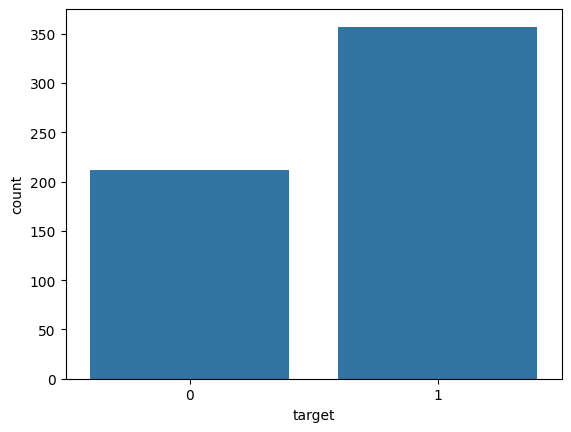

In [6]:
sns.countplot(x=df['target'])
plt.show()

In [7]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [8]:
#The prediction problem in the Breast Cancer Wisconsin Dataset is a binary classification task in which a Deep Learning model is trained to predict whether a breast tumor is malignant or benign using medical diagnostic features.

Step 2: Clean the Data

In [9]:
df.isna().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum().sum()

np.int64(0)

In [11]:
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [12]:
# We don't have any problem in data don't have any missing valuse , don't have any duplicates and all valuse numeircal valuse
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Step 3: Perform Simple EDA

<Axes: xlabel='target', ylabel='count'>

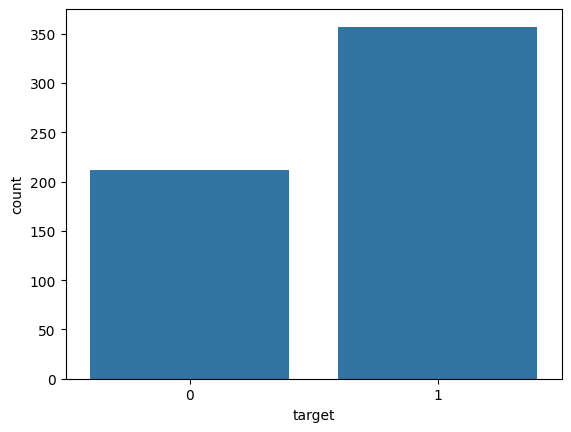

In [13]:
sns.countplot(x=df['target'])

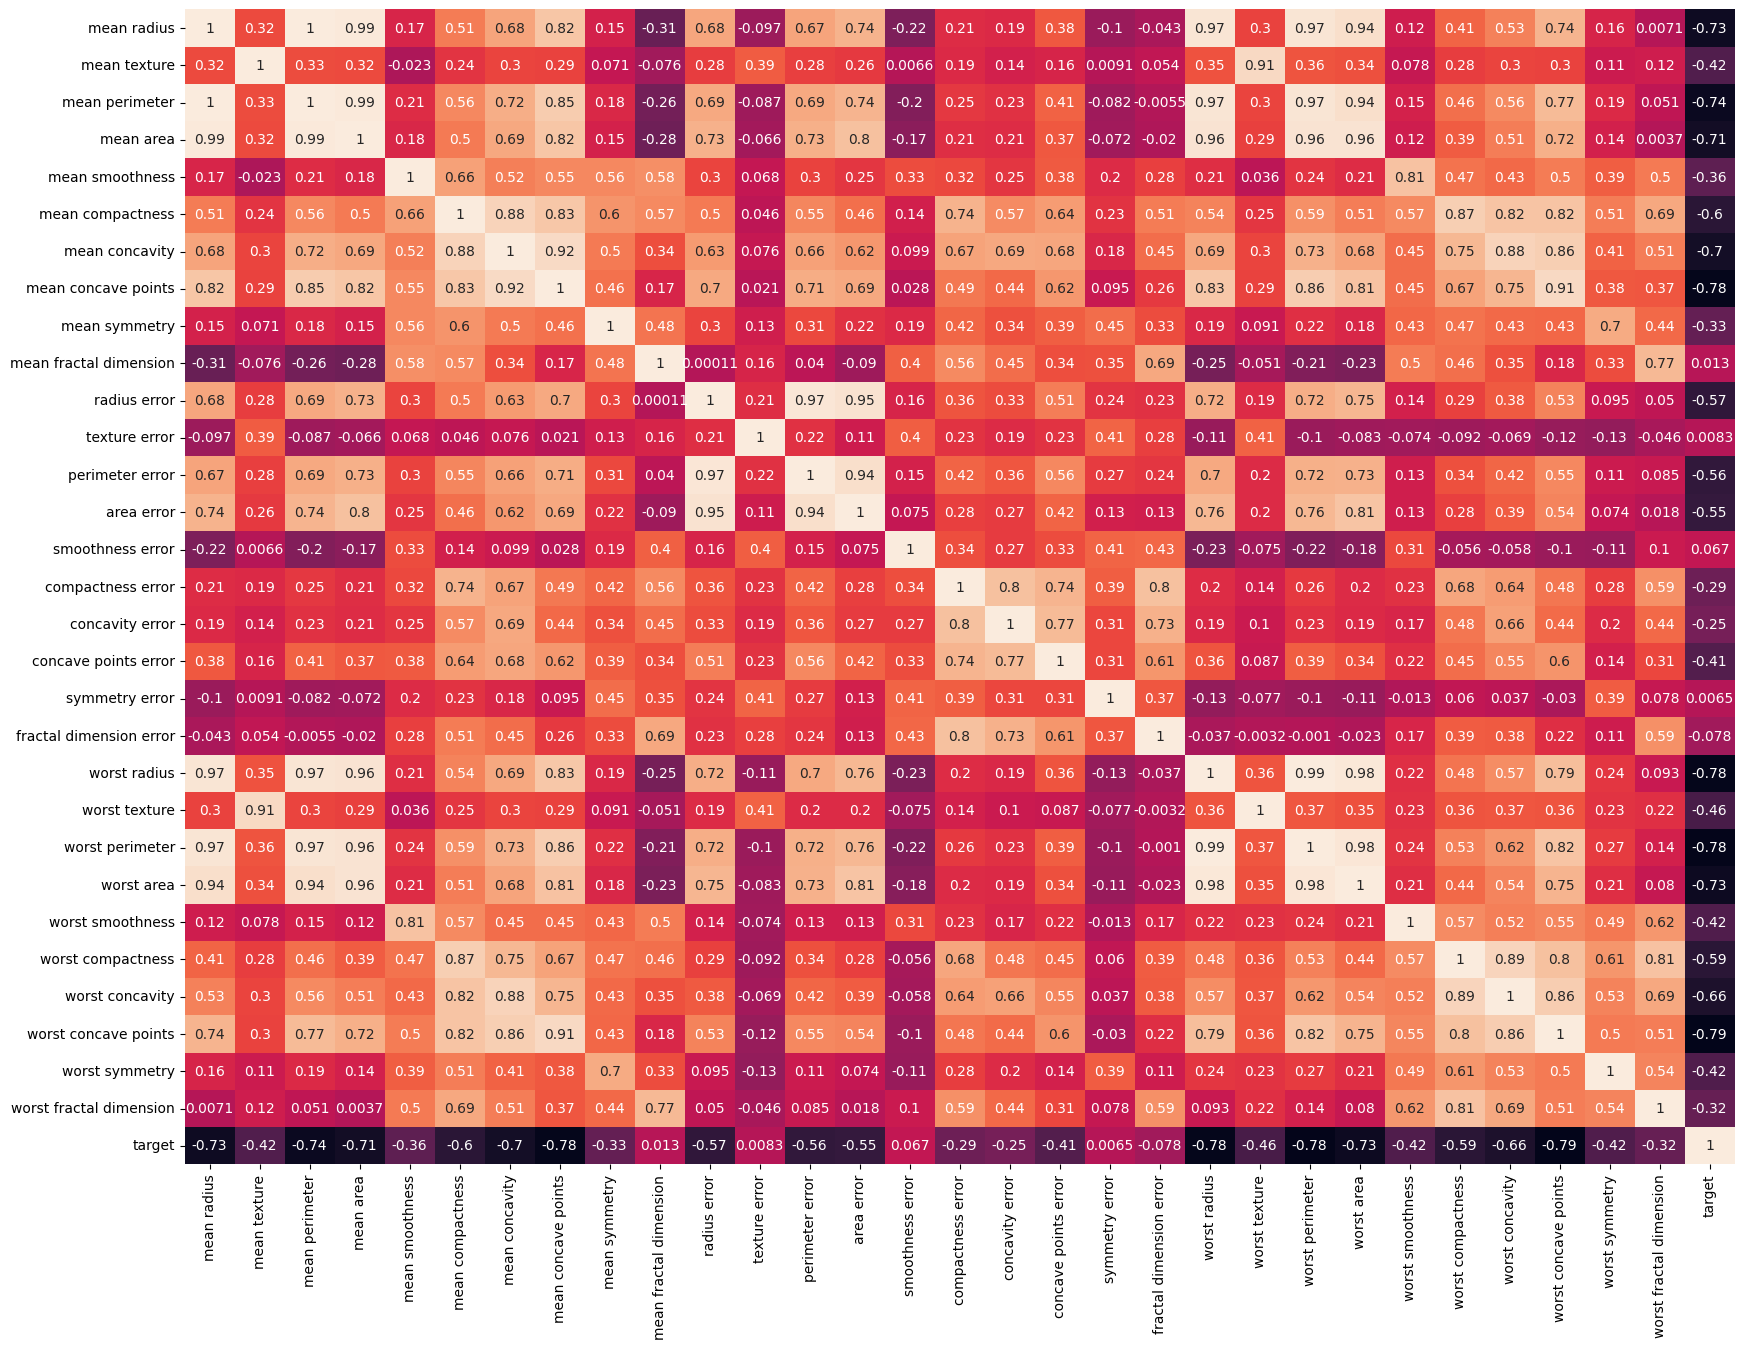

In [14]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), annot=True,cbar=False)
plt.show()

In [15]:
x=df.drop(['target'],axis=1)
y=df['target']

<Axes: >

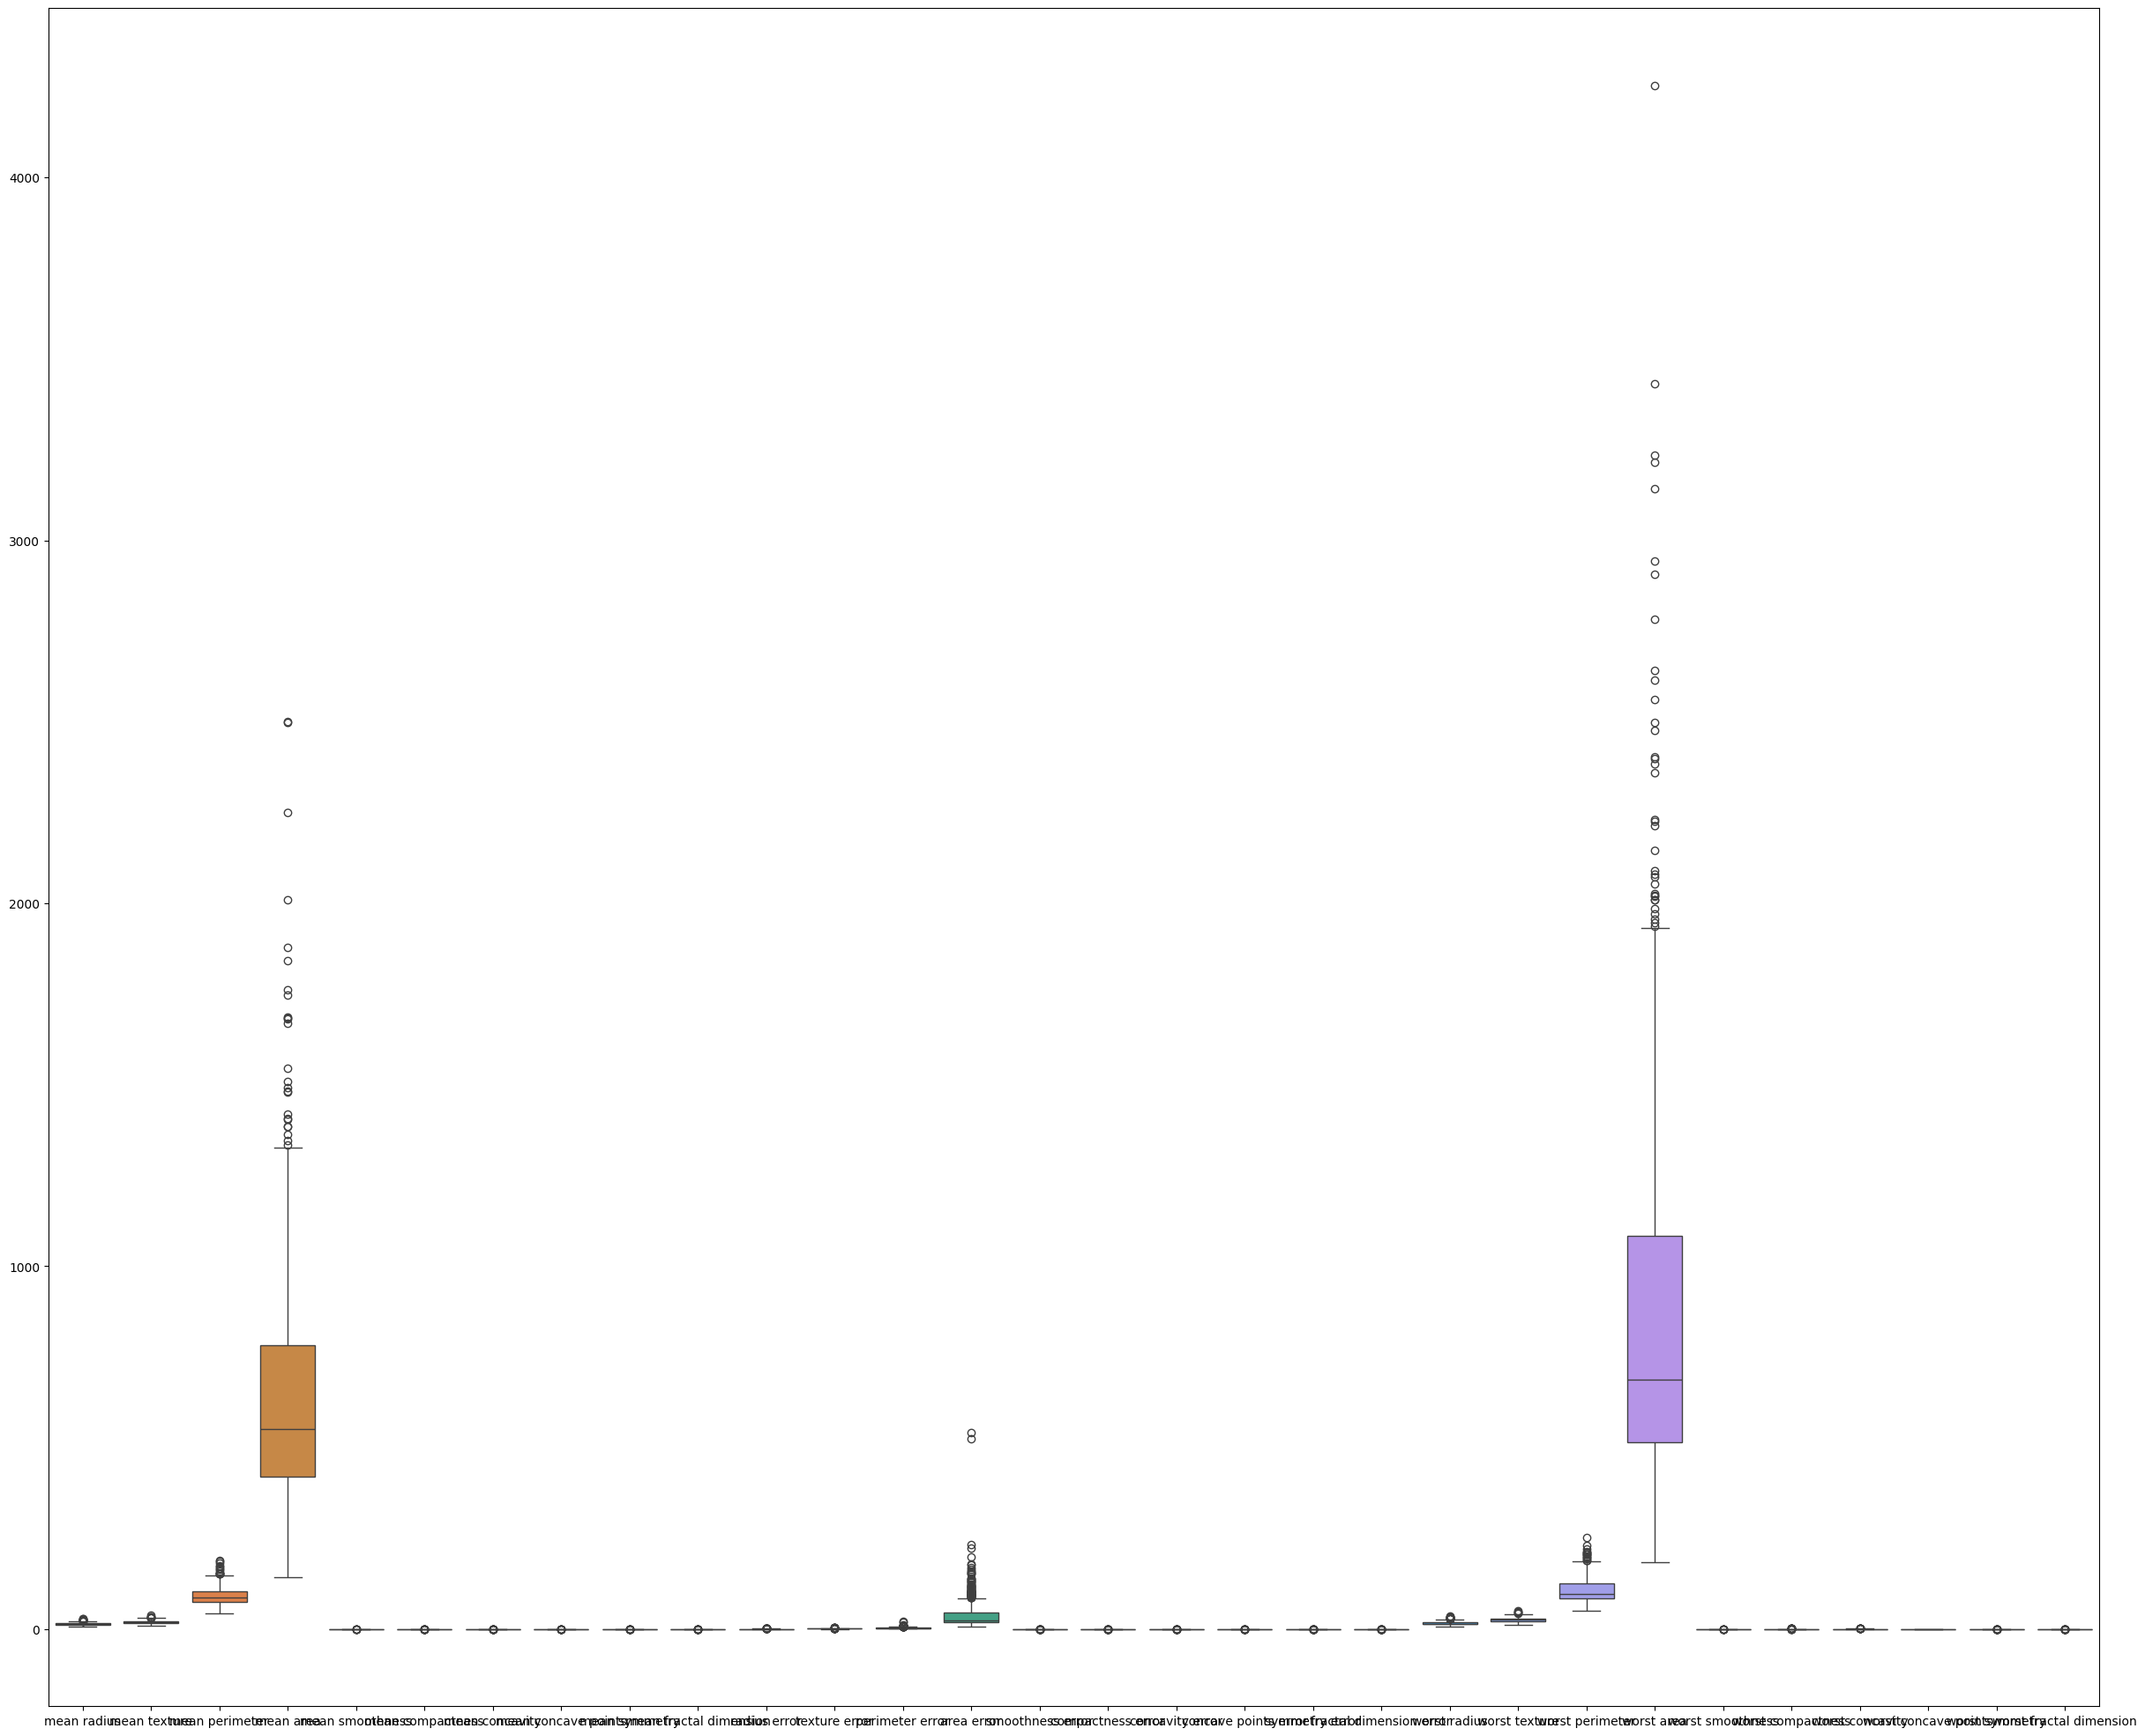

In [16]:
plt.figure(figsize=(30,25))
sns.boxplot(data=x)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


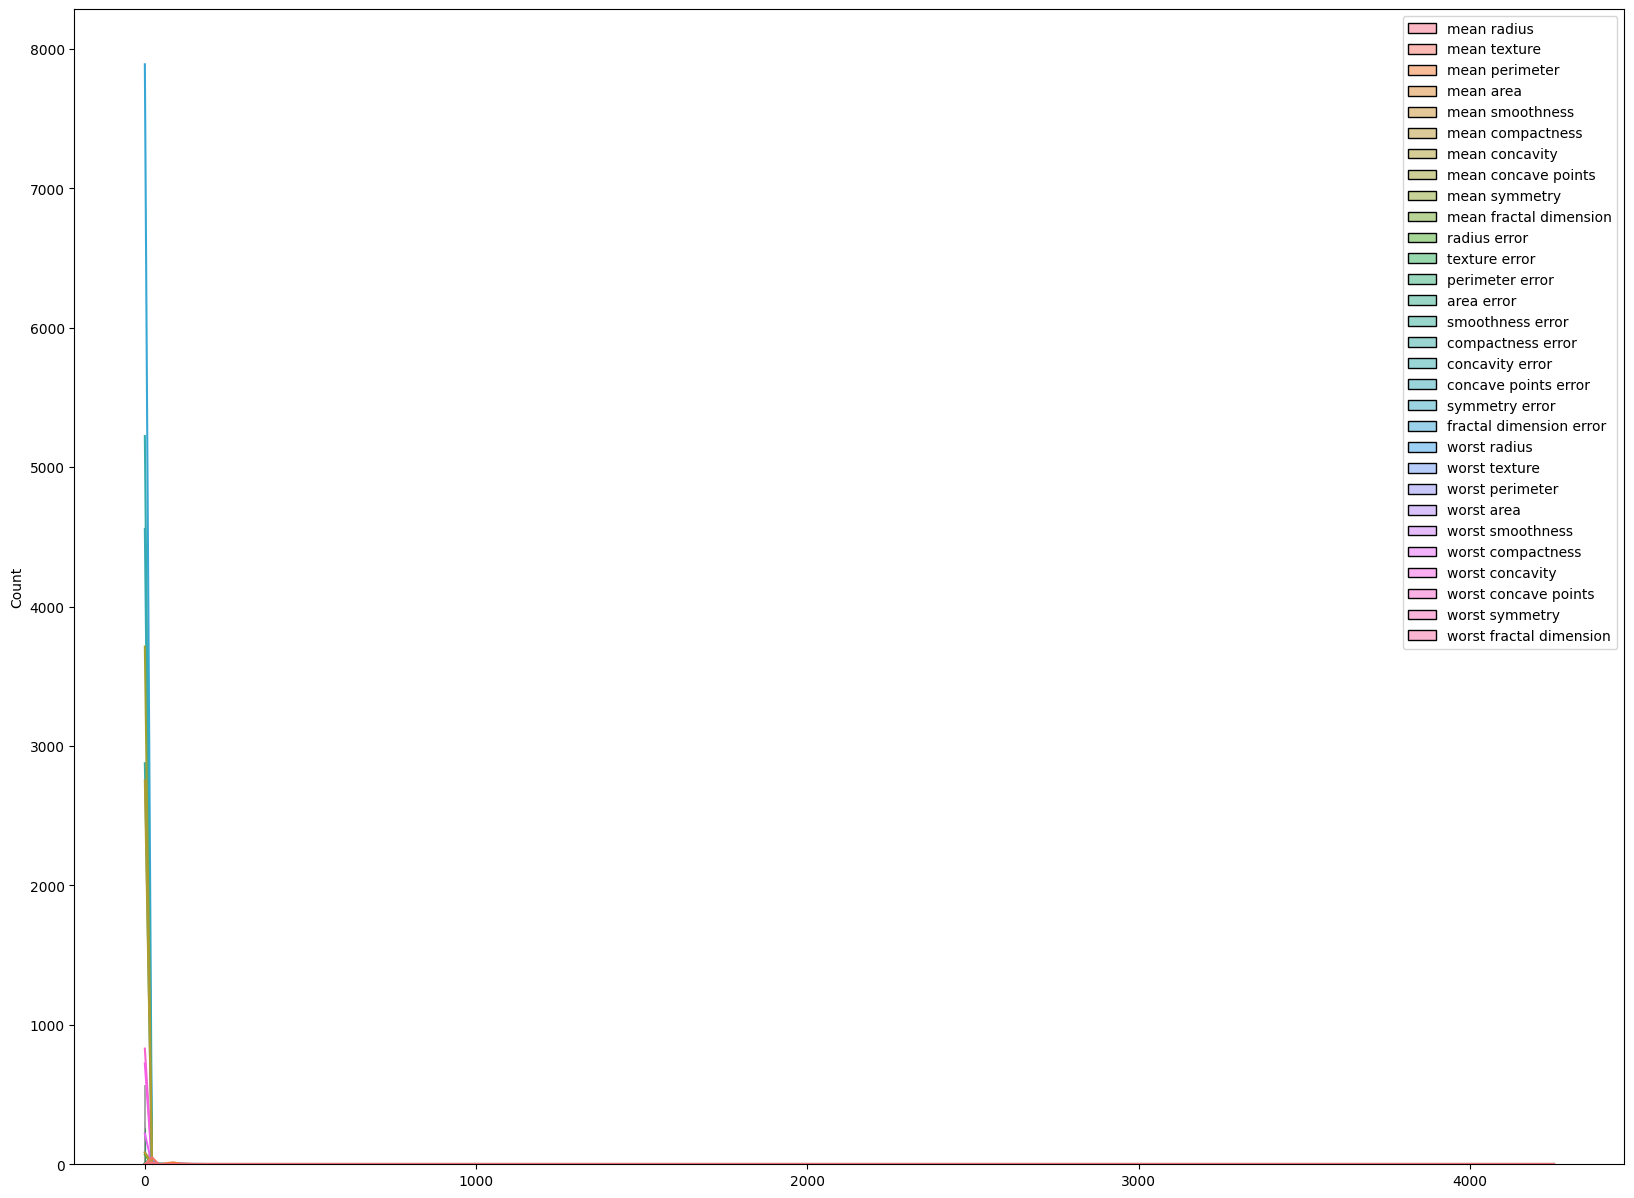

In [17]:
plt.figure(figsize=(20,15))
sns.histplot(x,kde=True)
plt.show()

In [18]:
#This data is imbalanced data
#Some features have highly correlated
#Some features have outliers

Step 4: Prepare the Features and Target

In [19]:
x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [20]:
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

In [21]:
# We don't have categorical features

In [22]:
#worst area	#mean area

In [23]:
Q1= df['mean area'].quantile(0.25)
Q3= df['mean area'].quantile(0.75)
IQR=Q3-Q1
lower_bound_mean_area=Q1-1.5*IQR
upper_bound_mean_area=Q3+1.5*IQR
df=df[(df['mean area'] >= lower_bound_mean_area) & (df['mean area'] <= upper_bound_mean_area)]

In [24]:
Q1= df['worst area'].quantile(0.25)
Q3= df['worst area'].quantile(0.75)
IQR=Q3-Q1
lower_bound_worst_area=Q1-1.5*IQR
upper_bound_worst_area=Q3+1.5*IQR
df=df[(df['worst area'] >= lower_bound_worst_area) & (df['worst area'] <= upper_bound_worst_area)]

<Axes: >

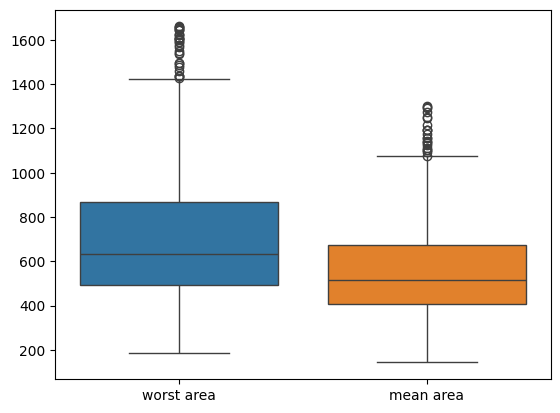

In [25]:
sns.boxplot(df[['worst area','mean area']])

In [26]:
df.reset_index(drop=True,inplace=True)

In [27]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,11.42,20.38,77.58,386.1,0.14250,0.2839,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
1,20.29,14.34,135.10,1297.0,0.10030,0.1328,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
2,12.45,15.70,82.57,477.1,0.12780,0.1700,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
3,18.25,19.98,119.60,1040.0,0.09463,0.1090,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
4,13.71,20.83,90.20,577.9,0.11890,0.1645,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0


Step 5: Train-Test Split

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [29]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(455, 30)
(455,)
(114, 30)
(114,)


Step 6: Scale the Data Without Data Leakage

In [30]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

Step 7: Build the Baseline ANN Model

In [31]:
model= Sequential()
model.add(Dense(64,input_dim=30,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779043696.103724      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Step 8: Train the Baseline Model

In [33]:
history=model.fit(x_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10


I0000 00:00:1779043699.210415     127 service.cc:152] XLA service 0x7fa0b8004370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779043699.210452     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779043699.498605     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/12 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5312 - loss: 0.7710

I0000 00:00:1779043700.486513     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.6671 - loss: 0.6698 - val_accuracy: 0.9121 - val_loss: 0.4536
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8956 - loss: 0.4085 - val_accuracy: 0.9560 - val_loss: 0.2922
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9204 - loss: 0.2759 - val_accuracy: 0.9451 - val_loss: 0.2022
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9290 - loss: 0.1943 - val_accuracy: 0.9451 - val_loss: 0.1557
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9653 - loss: 0.1401 - val_accuracy: 0.9451 - val_loss: 0.1271
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9525 - loss: 0.1374 - val_accuracy: 0.9560 - val_loss: 0.1076
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9570 - loss: 0.1212 - val_accuracy: 0.9670 - val_loss: 0.0912
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9811 - loss: 0.0847 - val_accuracy: 0.9780 - val_loss: 0.0790
E

Step 9: Evaluate the Baseline Model

In [34]:
y_pred_prob=model.predict(x_test)
y_pred=(y_pred_prob>0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [35]:
train_loss, train_accuracy = model.evaluate(x_train,y_train,verbose=True)
test_loss, test_accuracy = model.evaluate(x_test,y_test,verbose=True)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9758 - loss: 0.0791
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9558 - loss: 0.1063


In [36]:
cm=confusion_matrix(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print('confusion matrix')
print(cm)
print('precision_score',precision)
print('recall_score',recall)
print('f1_score',f1)

confusion matrix
[[40  2]
 [ 2 70]]
precision_score 0.9722222222222222
recall_score 0.9722222222222222
f1_score 0.9722222222222222


In [ ]:
class myHyperModel(HyperModel):
    def build(self,hp:HyperParameters):
        model= Sequential()
        model.add(input(shape=(30,)))
        n_hidden=hp.Int(name='n_hidden',min=2,max_value=4)

        for i in range(n_hidden):
            n_units=hp.Choice(name=f'n_units_{i+1}',values=[32,64,128])
            activation=hp.Choice(name=f'activation_{i+1}',values=['sigmoid','tanh','relu'])

            model.add(Dense(n_units,activation=activation))
        model.add(Dense(units=2,activation='sigmoid'))
        lr = hp.Float(name='learning_rate', min_value=1e-4, max_value=1e-3, sampling='log')
        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss='mse',
            metrics=['mae']
        )

        return model
    def fit(self,hp:HyperParameters,models,*args,**kwargs):
        return model.fit(
            *args,
            epochs= hp.Int('epochs', 5, 10, 5),
            batch_size = hp.Choice('bs', [32, 64]),
            **kwargs,
        )

In [50]:
random_tuner = RandomSearch(
    myHyperModel(),
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='kt_randomsearch',
)

random_tuner.search(
    x_train, y_train,
    validation_split=0.2,
)

best_random_params= random_tuner.get_best_hyperparameters((num_trials=1)[0])

print("Best HyperParameters:")
for param in best_random_params:
    print(param.values)

print("\n")


SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (2496915751.py, line 14)